## Titanic Survival Analysis

#### Objective
The objective of this project is to analyze the Titanic passenger dataset and identify factors that influenced passenger survival.

#### Tools Used
- Pandas
- NumPy
- Matplotlib
- Seaborn

#### Dataset
Titanic passenger dataset from Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Optional for prettier plots
sns.set_style("whitegrid")

In [2]:
df= pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Dataset Overview
- The dataset contains information about 891 Titanic passengers.
- There are 12 features describing passengers.
- The target variable is "Survived".

- Survival is represented as a binary variable:
  - 0 = Did Not Survive
  - 1 = Survived

- Cabin contains a very large number of missing values (~77%).
- Cabin may require special handling or removal during preprocessing.

- Age contains 177 missing values.
- Since age may influence survival, the column should be retained and missing values handled appropriately.

--Numerical data--                  
PassengerId
Survived
Pclass
Age
SibSp
Parch
Fare
 --categorical data--
Sex
Embarked
Ticket
Cabin
Name

How many people survived?

In [7]:
df["Survived"].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
s_p = df["Survived"].value_counts(normalize = True)*100
print(s_p)


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


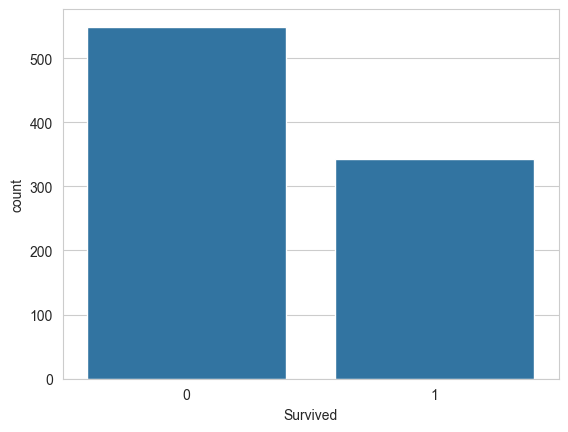

In [12]:
sns.countplot(data=df,x="Survived")
plt.show()

##### Survival Analysis
- Out of 891 passengers, 342 survived and 549 died.
- Approximately 38.4% of passengers survived.
- Approximately 61.6% of passengers did not survive.
- The majority of passengers aboard the Titanic did not survive.

 Did Gender Affect Survival?

In [13]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

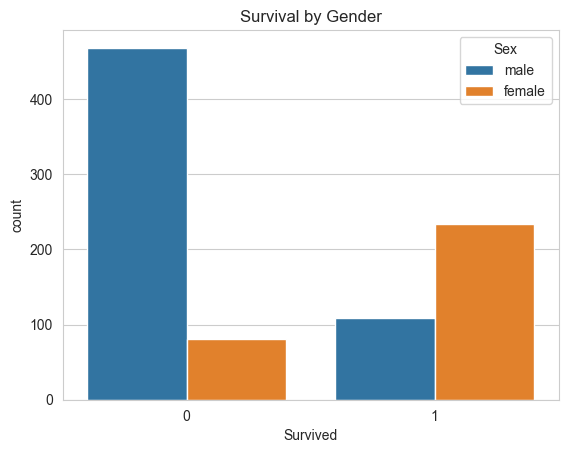

In [19]:
sns.countplot(data=df, x="Survived", hue="Sex")
plt.title("Survival by Gender")
plt.show()

#### Gender and Survival
- Female passengers had a survival rate of approximately 74.2%.
- Male passengers had a survival rate of approximately 18.9%.
- Gender appears to be a strong factor influencing survival.
- Female passengers were significantly more likely to survive than male passengers.

Did richer passengers survive more often?

In [21]:
df.groupby("Pclass")["Survived"].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

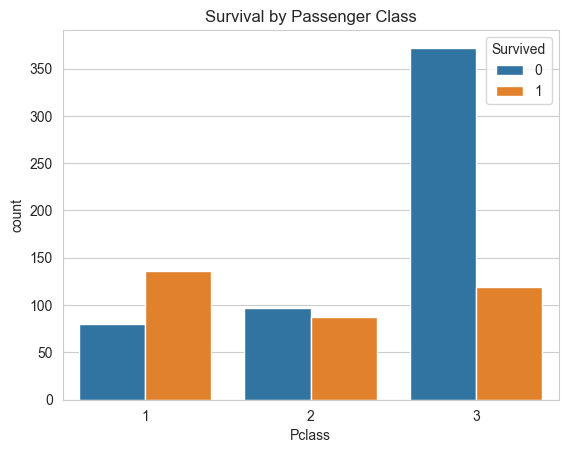

In [22]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

#### Passenger Class and Survival
- First-class passengers had the highest survival rate (~63%).
- Second-class passengers had a moderate survival rate (~47%).
- Third-class passengers had the lowest survival rate (~24%).
- Passenger class appears to have a strong relationship with survival.

In [25]:
df.groupby("Pclass")["Sex"].value_counts()

Pclass  Sex   
1       male      122
        female     94
2       male      108
        female     76
3       male      347
        female    144
Name: count, dtype: int64

In [28]:
pd.crosstab(df["Pclass"], df["Sex"], values=df["Survived"], aggfunc="mean")

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


#### Combined Effect of Gender and Passenger Class
- First-class females had the highest survival rate (~96.8%).
- Third-class males had the lowest survival rate (~13.5%).
- Gender appears to have a stronger influence on survival than passenger class.
- Passenger class also plays an important role, especially among female passengers.
- Even third-class females had a higher survival rate than first-class males.

- Now let’s see whether age mattered.
- Did younger passengers survive more?
- Did older passengers survive less?

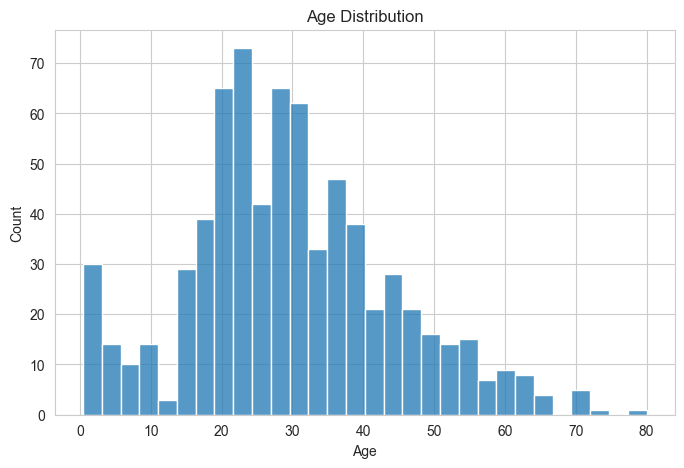

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")
plt.show()

In [31]:
df.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

#### Age and Survival
- The average age of survivors was approximately 28.3 years.
- The average age of non-survivors was approximately 30.6 years.
- The difference is relatively small.
- Age does not appear to be as strong a factor as gender or passenger class.

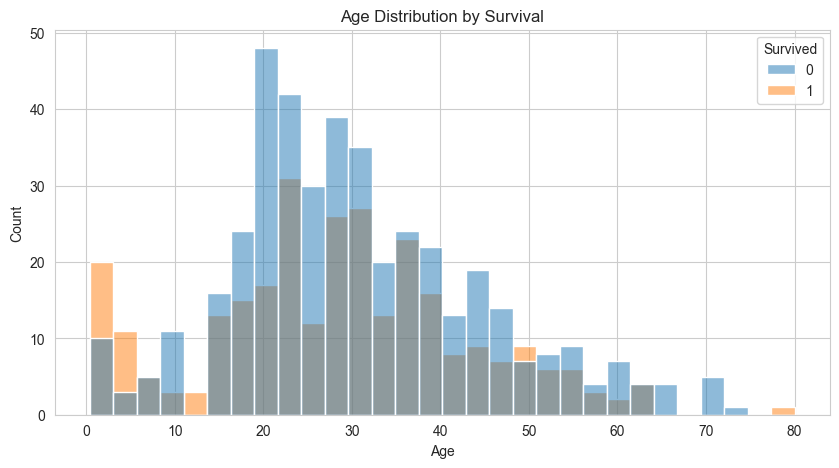

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30)
plt.title("Age Distribution by Survival")
plt.show()

Next Investigation: Fare (Money)

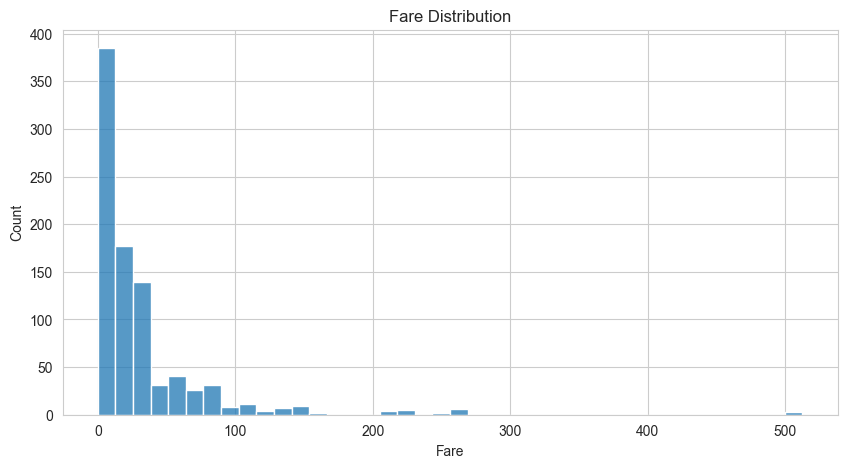

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df["Fare"], bins=40)
plt.title("Fare Distribution")
plt.show()

In [34]:
df.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

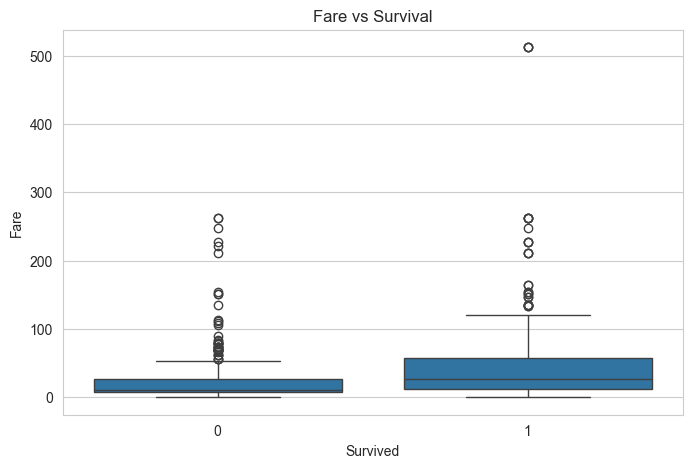

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare vs Survival")
plt.show()

#### Fare Analysis
- Survivors paid an average fare of approximately 48.4.
- Non-survivors paid an average fare of approximately 22.1.
- Survivors generally paid higher fares.
- Fare appears to have a positive relationship with survival.
- This may be related to passenger class, as first-class passengers typically paid higher fares.

In [36]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

#### Embarkation Port Analysis
- Passengers boarding from Cherbourg had the highest survival rate (~55%).
- Passengers boarding from Southampton had the lowest survival rate (~34%).
- Embarkation port appears to be associated with survival.
- Further investigation would be needed to determine whether this relationship is influenced by passenger class or other factors.

## Final Conclusions
1. Approximately 38.4% of passengers survived, while 61.6% did not survive.
2. Gender was one of the strongest predictors of survival.
   - Female survival rate: ~74%
   - Male survival rate: ~19%
3. Passenger class had a significant impact on survival.
   - First Class: ~63%
   - Second Class: ~47%
   - Third Class: ~24%
4. First-class females had the highest survival rate (~97%).
5. Third-class males had the lowest survival rate (~14%).
6. Survivors generally paid higher fares than non-survivors.
7. Age showed a weaker relationship with survival compared to gender and class.
8. Passengers embarking from Cherbourg had the highest survival rate among the three embarkation ports.